# Drug Classification with Decision Trees

**Course:** IBM Machine Learning with Python

## Objective
Build a `DecisionTreeClassifier` that predicts which drug (A, B, C, X, or Y) a patient should be prescribed, based on features such as **Age**, **Sex**, **Blood Pressure (BP)**, **Cholesterol**, and **Na_to_K ratio**.

## Workflow
1. Install and import required libraries
2. Load and explore the dataset
3. Preprocess data (encode categorical features, map target labels)
4. Explore feature correlation and class distribution
5. Split data into train/test sets
6. Train a Decision Tree model
7. Evaluate accuracy
8. Visualize the tree
9. Compare a shallower tree (max_depth=3)

## 1. Install Dependencies
Pin package versions so the notebook behaves the same way on any machine.

In [1]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 1.7 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/12.6 MB 3.1 MB/s eta 0:00:04
   --------- ------------------------------ 3.1/12.6 MB 5.3 MB/s eta 0:00:02
   ---------------------- ----------------- 7.1/12.6 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 13.1 MB/s  0:00:01


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.5 MB 1.8 MB/s eta 0:00:07
   ---- ----------------------------------- 1.3/11.5 MB 3.0 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/11.5 MB 5.1 MB/s eta 0:00:02
   ---------------------- ----------------- 6.6/11.5 MB 8.1 MB/s eta 0:00:01
   -------------------------------- ------- 9.4/11.5 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 10.1 MB/s  0:00:01


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 1.7 MB/s eta 0:00:07
   ------- -------------------------------- 2.1/11.1 MB 4.3 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 5.5 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.1 MB 6.4 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 7.0 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 7.6 MB/s  0:00:01
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -------------------------

## 2. Imports
- `numpy` / `pandas`: numeric and tabular data handling
- `matplotlib`: plotting
- `LabelEncoder`: converts text categories (e.g. `"F"/"M"`) into integers
- `train_test_split`: splits data into training and testing sets
- `DecisionTreeClassifier`, `plot_tree`: the model and its visualization
- `metrics`: to score the model's predictions

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 3. Load the Dataset
The `drug200.csv` dataset contains 200 patient records. Each row has patient attributes and the drug that was effective for them.

In [3]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


## 4. Inspect Data Types and Structure
`.info()` shows column names, data types, and non-null counts — useful for spotting missing values or wrong dtypes before modeling.

In [4]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


## 5. Encode Categorical Features
Decision trees in scikit-learn require numeric input. `LabelEncoder` maps each category to an integer, e.g. `Sex`: `F -> 0`, `M -> 1`. The same approach is applied to `BP` and `Cholesterol`.

In [5]:
label_encoder = LabelEncoder()
my_data['Sex'] = label_encoder.fit_transform(my_data['Sex'])
my_data['BP'] = label_encoder.fit_transform(my_data['BP'])
my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


## 6. Check for Missing Values
`.isnull().sum()` counts nulls per column. A clean result (all zeros) means no imputation is needed.

In [6]:
my_data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

## 7. Map the Target Label to Numbers
The target column `Drug` is text (`drugA`...`drugY`). A manual mapping (`custom_map`) creates a numeric column `Drug_num`, which is handy for correlation analysis (correlation only works on numeric data).

In [7]:
custom_map = {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY': 4}
my_data['Drug_num'] = my_data['Drug'].map(custom_map)
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Drug_num
0,23,0,0,0,25.355,drugY,4
1,47,1,1,0,13.093,drugC,2
2,47,1,1,0,10.114,drugC,2
3,28,0,2,0,7.798,drugX,3
4,61,0,1,0,18.043,drugY,4
...,...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC,2
196,16,1,1,0,12.006,drugC,2
197,52,1,2,0,9.894,drugX,3
198,23,1,2,1,14.020,drugX,3


## 8. Correlation with the Target
Shows how linearly each feature relates to `Drug_num`. Note: this is only a rough signal — decision trees can capture non-linear relationships that correlation won't reveal.

In [8]:
my_data.drop('Drug', axis=1).corr()['Drug_num']

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

## 9. Visualize Class Distribution
A bar chart of how many patients received each drug. Useful for spotting class imbalance, which can bias the model toward the majority class.

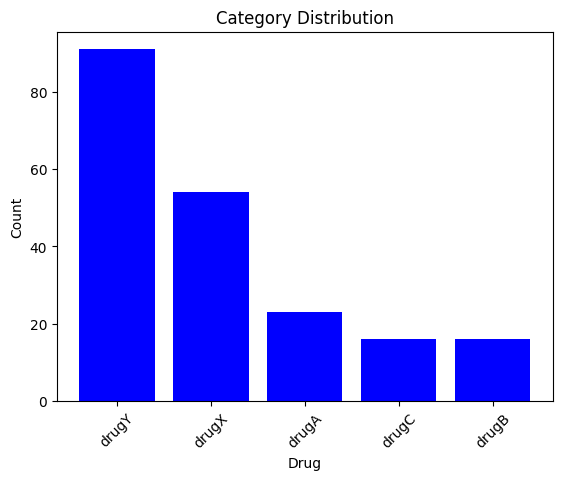

In [9]:
category_counts = my_data['Drug'].value_counts()

plt.bar(category_counts.index, category_counts.values, color='blue')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Category Distribution')
plt.xticks(rotation=45)
plt.show()

## 10. Define Features (X) and Target (y)
`y` is the label we want to predict (`Drug`, the original text column — sklearn can classify string labels directly). `X` is every other column except `Drug` and the helper `Drug_num` column.

In [10]:
y = my_data['Drug']
X = my_data.drop(['Drug', 'Drug_num'], axis=1)

## 11. Train/Test Split
Hold out 30% of the data for testing so we can evaluate the model on unseen samples. `random_state` makes the split reproducible.

In [11]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32)

## 12. Build and Train the Decision Tree
- `criterion="entropy"`: splits are chosen to maximize information gain
- `max_depth=4`: limits tree depth to 4 levels to reduce overfitting
- `.fit()` trains the model on the training set

In [12]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
drugTree.fit(X_trainset, y_trainset)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

## 13. Predict on the Test Set

In [13]:
tree_predictions = drugTree.predict(X_testset)

## 14. Evaluate Accuracy
Compares predicted labels (`tree_predictions`) against the true labels (`y_testset`) and reports the fraction of correct predictions.

In [14]:
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

Decision Trees's Accuracy:  0.9833333333333333


## 15. Visualize the Tree
`plot_tree` draws the decision rules learned by the model — each node shows the split condition, entropy, sample count, and class distribution.

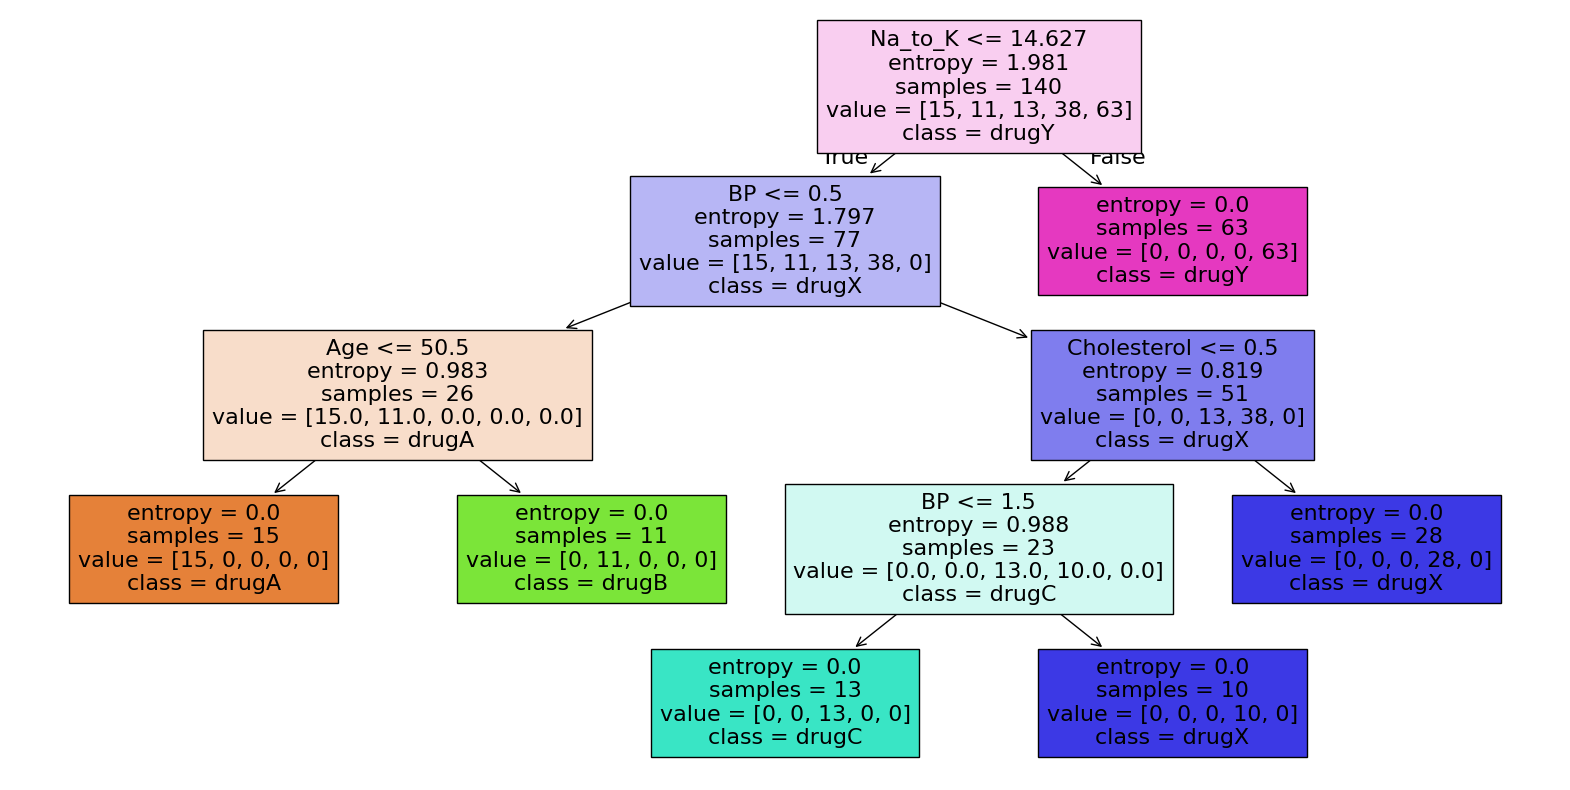

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(drugTree, feature_names=X.columns, class_names=drugTree.classes_, filled=True)
plt.show()

## 16. Compare a Shallower Tree (max_depth=3)
Retrain with a shallower tree to see the accuracy/complexity trade-off. A shallower tree is simpler and easier to interpret but may lose some accuracy if depth 4 was capturing useful patterns.

In [16]:
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth=3)
drugTree.fit(X_trainset, y_trainset)
tree_predictions = drugTree.predict(X_testset)
print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

Decision Trees's Accuracy:  0.8166666666666667


## Conclusion
The Decision Tree model classifies which drug fits a patient based on Age, Sex, BP, Cholesterol, and Na_to_K. Tuning `max_depth` trades off model complexity against accuracy — a deeper tree can overfit, while too shallow a tree may underfit.